In [1]:
# === GLOBAL IMPORTS & SEED FIXING ===
import os
import gc
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Fix random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

# Sklearn
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.utils import shuffle

# Keras (modern TF imports only)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
)
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)
print("Seed fixed:", SEED)
from xgboost import XGBClassifier

2026-05-18 07:21:50.908459: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779088911.116397      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779088911.171195      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779088911.673150      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779088911.673194      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779088911.673197      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: True
Seed fixed: 42


In [2]:
!pip install xgboost


## Helper Functions

In [3]:
# === HELPER: Compute specificity from confusion matrix ===
def compute_specificity(cm):
    """Compute mean specificity across all classes from a confusion matrix."""
    spec_list = []
    for i in range(len(cm)):
        TP = cm[i, i]
        FN = np.sum(cm[i, :]) - TP
        FP = np.sum(cm[:, i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)
        denom = TN + FP
        spec = TN / denom if denom > 0 else 0.0
        spec_list.append(spec)
    return float(np.mean(spec_list))


# === HELPER: Print metrics table ===
def print_metrics(split_name, accuracy, f1, sensitivity, specificity):
    print(f"\n{'='*50}")
    print(f" {split_name} METRICS")
    print(f"{'='*50}")
    print(f"  Accuracy    : {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  F1-Score    : {f1:.4f}")
    print(f"  Sensitivity : {sensitivity:.4f}")
    print(f"  Specificity : {specificity:.4f}")
    print(f"{'='*50}")


# === HELPER: Compute all binary/multiclass metrics ===
def compute_metrics(y_true, y_pred, average='weighted'):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average=average, zero_division=0)
    sens = recall_score(y_true, y_pred, average=average, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)
    spec = compute_specificity(cm)
    return acc, f1, sens, spec, cm


# === HELPER: Plot confusion matrix ===
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix', figsize=(6,5)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [4]:
# === DATASET PATHS ===
CHEST_BASE = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/'
CHEST_TRAIN_DIR = CHEST_BASE + 'train/'
CHEST_TEST_DIR  = CHEST_BASE + 'test/'
CHEST_VAL_DIR   = CHEST_BASE + 'val/'

CLASSES = {'NORMAL': 0, 'PNEUMONIA': 1}
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']
IMG_SIZE_SVM = 200   # for SVM (grayscale)
IMG_SIZE_CNN = 224   # for CNN (RGB)

# === LOAD DATA FOR SVM (grayscale, flattened) ===
def load_svm_data(base_dir, classes, img_size=200):
    """Load grayscale images, resize, flatten, and normalize for SVM.""" 
    X, y = [], []
    for cls, label in classes.items():
        folder = os.path.join(base_dir, cls)
        for fname in sorted(os.listdir(folder)):
            fpath = os.path.join(folder, fname)
            img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            X.append(img.flatten() / 255.0)
            y.append(label)
    return np.array(X), np.array(y)


print("Loading Chest training data (grayscale) from train/ ...")
X_train_flat, y_train = load_svm_data(CHEST_TRAIN_DIR, CLASSES, IMG_SIZE_SVM)
print(f"  Train shape: {X_train_flat.shape}, Labels: {np.bincount(y_train)}")

print("\nLoading Chest test data (grayscale) from test/ ...")
X_test_flat, y_test = load_svm_data(CHEST_TEST_DIR, CLASSES, IMG_SIZE_SVM)
print(f"  Test shape : {X_test_flat.shape}, Labels: {np.bincount(y_test)}")

Loading Chest training data (grayscale) from train/ ...
  Train shape: (5216, 40000), Labels: [1341 3875]

Loading Chest test data (grayscale) from test/ ...
  Test shape : (624, 40000), Labels: [234 390]


In [5]:
# ==============================================================
# BRAIN TUMOR DATASET PATHS
# ==============================================================

BRAIN_BASE = '/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/'

BRAIN_TRAIN_DIR = BRAIN_BASE + 'Training/'
BRAIN_TEST_DIR  = BRAIN_BASE + 'Testing/'

BRAIN_CLASSES = {'no_tumor': 0, 'pituitary_tumor': 1, 'glioma_tumor': 2, 'meningioma_tumor': 3}
BRAIN_CLASS_NAMES = ['No Tumor', 'Pituitary', 'Glioma', 'Meningioma']
IMG_SIZE_BRAIN = 200
# ==============================================================
# LOAD BRAIN MRI DATA FOR CLASSICAL ML
# ==============================================================

def load_brain_data(base_dir, classes, img_size=200):

    X = []
    y = []

    for cls, label in classes.items():

        folder = os.path.join(base_dir, cls)

        for fname in sorted(os.listdir(folder)):

            fpath = os.path.join(folder, fname)

            img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (img_size, img_size))

            X.append(img.flatten() / 255.0)

            y.append(label)

    return np.array(X), np.array(y)

print("\nLoading Brain Tumor training data...")

X_brain_train_flat, y_brain_train = load_brain_data(BRAIN_TRAIN_DIR, BRAIN_CLASSES, IMG_SIZE_BRAIN)

print(f"Train shape : {X_brain_train_flat.shape}")
print(f"Train labels: {np.bincount(y_brain_train)}")

print("\nLoading Brain Tumor testing data...")

X_brain_test_flat, y_brain_test = load_brain_data(BRAIN_TEST_DIR, BRAIN_CLASSES, IMG_SIZE_BRAIN)

print(f"Test shape  : {X_brain_test_flat.shape}")
print(f"Test labels : {np.bincount(y_brain_test)}")


Loading Brain Tumor training data...
Train shape : (2870, 40000)
Train labels: [395 827 826 822]

Loading Brain Tumor testing data...
Test shape  : (394, 40000)
Test labels : [105  74 100 115]



XGBOOST — CHEST X-RAY

 XGBOOST CHEST TEST METRICS
  Accuracy    : 0.7228  (72.28%)
  F1-Score    : 0.6703
  Sensitivity : 0.7228
  Specificity : 0.6329


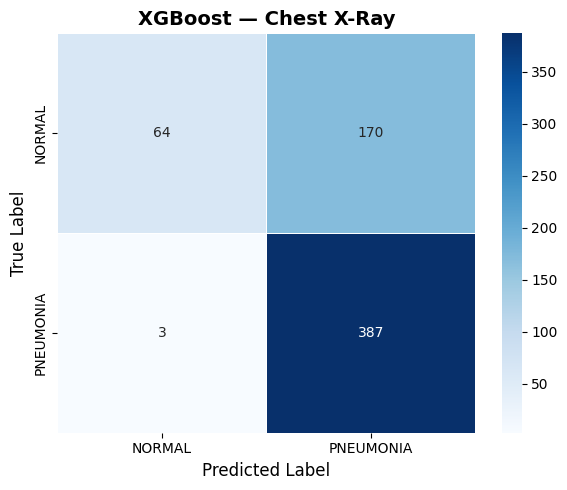

In [6]:
# ==============================================================
# XGBOOST — CHEST X-RAY
# ==============================================================

print("\n" + "="*70)
print("XGBOOST — CHEST X-RAY")
print("="*70)

xgb_chest = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=SEED
)

xgb_chest.fit(X_train_flat, y_train)

pred_xgb_chest = xgb_chest.predict(X_test_flat)

xgb_chest_metrics = compute_metrics(y_test, pred_xgb_chest)
print_metrics("XGBOOST CHEST TEST", *xgb_chest_metrics[:4])
plot_confusion_matrix(xgb_chest_metrics[4], CLASS_NAMES, title='XGBoost — Chest X-Ray')


XGBOOST — BRAIN MRI
[0]	validation_0-mlogloss:1.20209
[1]	validation_0-mlogloss:1.08204
[2]	validation_0-mlogloss:0.98243
[3]	validation_0-mlogloss:0.89448
[4]	validation_0-mlogloss:0.81853
[5]	validation_0-mlogloss:0.75053
[6]	validation_0-mlogloss:0.69084
[7]	validation_0-mlogloss:0.63600
[8]	validation_0-mlogloss:0.58757
[9]	validation_0-mlogloss:0.54488
[10]	validation_0-mlogloss:0.50520
[11]	validation_0-mlogloss:0.46800
[12]	validation_0-mlogloss:0.43431
[13]	validation_0-mlogloss:0.40399
[14]	validation_0-mlogloss:0.37597
[15]	validation_0-mlogloss:0.35100
[16]	validation_0-mlogloss:0.32702
[17]	validation_0-mlogloss:0.30566
[18]	validation_0-mlogloss:0.28539
[19]	validation_0-mlogloss:0.26844
[20]	validation_0-mlogloss:0.25095
[21]	validation_0-mlogloss:0.23599
[22]	validation_0-mlogloss:0.22128
[23]	validation_0-mlogloss:0.20828
[24]	validation_0-mlogloss:0.19578
[25]	validation_0-mlogloss:0.18448
[26]	validation_0-mlogloss:0.17462
[27]	validation_0-mlogloss:0.16559
[28]	vali

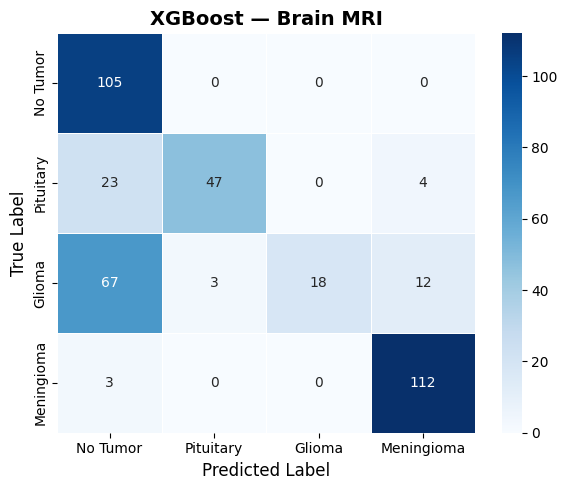

In [7]:
# ==============================================================
# XGBOOST — BRAIN MRI
# ==============================================================

print("\n" + "="*70)
print("XGBOOST — BRAIN MRI")
print("="*70)

xgb_brain = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=SEED
)

# xgb_brain.fit(X_brain_train_flat, y_brain_train, verbose = True)
xgb_brain.fit(X_brain_train_flat, y_brain_train, eval_set=[ (X_brain_train_flat, y_brain_train)], verbose=True)
pred_xgb_brain = xgb_brain.predict(X_brain_test_flat)

xgb_brain_metrics = compute_metrics(y_brain_test, pred_xgb_brain)
print_metrics("XGBOOST BRAIN TEST", *xgb_brain_metrics[:4])

plot_confusion_matrix( xgb_brain_metrics[4], BRAIN_CLASS_NAMES, title='XGBoost — Brain MRI')

In [8]:
# ==============================================================
# APPLY PCA ON CHEST CT DATA
# ==============================================================

print("\nApplying PCA on Chest training data...")

pca = PCA(n_components=0.98, random_state=SEED)
pca_train = pca.fit_transform(X_train_flat)
pca_test = pca.transform(X_test_flat)
print(f"Original feature size : {X_train_flat.shape[1]}")
print(f"PCA components kept   : {pca.n_components_}")
print(f"Variance retained     : "f"{sum(pca.explained_variance_ratio_) * 100:.2f}%")
print(f"PCA train shape       : {pca_train.shape}")
print(f"PCA test shape        : {pca_test.shape}")


Applying PCA on Chest training data...
Original feature size : 40000
PCA components kept   : 1723
Variance retained     : 98.00%
PCA train shape       : (5216, 1723)
PCA test shape        : (624, 1723)


In [9]:
# ==============================================================
# PCA FOR BRAIN MRI DATA
# ==============================================================

print("\nApplying PCA on Brain MRI dataset...")

pca_brain = PCA(n_components=0.98, random_state=SEED)
pca_brain_train = pca_brain.fit_transform(X_brain_train_flat)
pca_brain_test = pca_brain.transform(X_brain_test_flat)
print(f"Original size : {X_brain_train_flat.shape[1]}")
print(f"PCA components: {pca_brain.n_components_}")
print(f"Variance kept : "f"{sum(pca_brain.explained_variance_ratio_) * 100:.2f}%")
print(f"PCA train shape       : {pca_brain_train.shape}")
print(f"PCA test shape        : {pca_brain_test.shape}")


Applying PCA on Brain MRI dataset...
Original size : 40000
PCA components: 1505
Variance kept : 98.00%
PCA train shape       : (2870, 1505)
PCA test shape        : (394, 1505)



XGBOOST — CHEST X-RAY

 XGBOOST CHEST TEST METRICS
  Accuracy    : 0.7564  (75.64%)
  F1-Score    : 0.7230
  Sensitivity : 0.7564
  Specificity : 0.6803


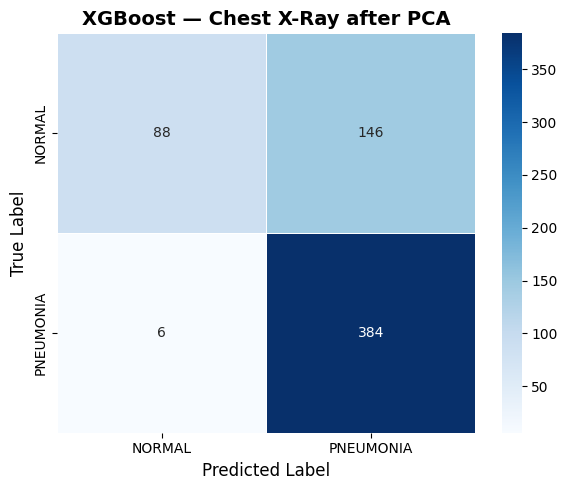

In [10]:
# ==============================================================
# XGBOOST — CHEST X-RAY
# ==============================================================

print("\n" + "="*70)
print("XGBOOST — CHEST X-RAY")
print("="*70)

xgb_chest = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=SEED
)

xgb_chest.fit(pca_train, y_train)

pred_xgb_chest_pca = xgb_chest.predict(pca_test)

xgb_chest_metrics_pca = compute_metrics(y_test, pred_xgb_chest_pca)
print_metrics("XGBOOST CHEST TEST", *xgb_chest_metrics_pca[:4])

plot_confusion_matrix(xgb_chest_metrics_pca[4], CLASS_NAMES, title='XGBoost — Chest X-Ray after PCA')


XGBOOST — BRAIN MRI

 XGBOOST BRAIN TEST METRICS
  Accuracy    : 0.7868  (78.68%)
  F1-Score    : 0.7424
  Sensitivity : 0.7868
  Specificity : 0.9274


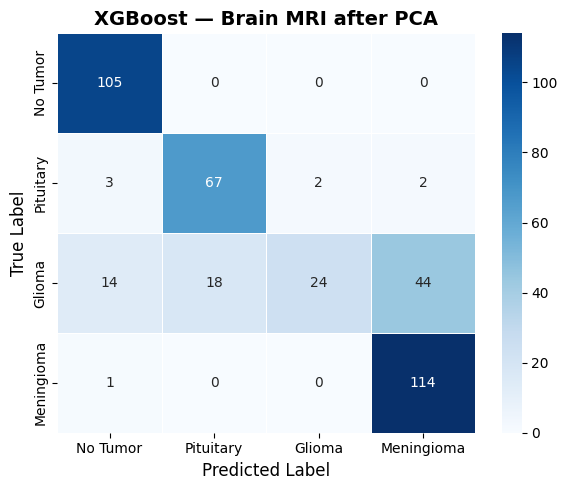

In [11]:
# ==============================================================
# XGBOOST — BRAIN MRI
# ==============================================================

print("\n" + "="*70)
print("XGBOOST — BRAIN MRI")
print("="*70)

xgb_brain = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=SEED
)

xgb_brain.fit(pca_brain_train, y_brain_train)
pred_xgb_brain_pca = xgb_brain.predict(pca_brain_test)

xgb_brain_metrics_pca = compute_metrics(y_brain_test, pred_xgb_brain_pca)
print_metrics("XGBOOST BRAIN TEST", *xgb_brain_metrics_pca[:4])

plot_confusion_matrix( xgb_brain_metrics_pca[4], BRAIN_CLASS_NAMES, title='XGBoost — Brain MRI after PCA')

# VGG-16 + XGBoost

In [12]:
# ==============================================================
# LOAD DATA FOR VGG16 FEATURE EXTRACTION
# ==============================================================

def load_vgg_data(base_dir, classes, img_size=(224, 224)):

    images = []
    labels = []

    for cls, label in classes.items():
        folder = os.path.join(base_dir, cls)
        for fname in sorted(os.listdir(folder)):
            fpath = os.path.join(folder, fname)
            img = cv2.imread(fpath)
            if img is None:
                continue
            # BGR → RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # Resize
            img = cv2.resize(img, img_size)
            # Normalize
            img = preprocess_input(img.astype(np.float32))
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

In [13]:
from tensorflow.keras.applications.vgg16 import preprocess_input

# ==============================================================
# LOAD CHEST X-RAY DATA FOR VGG16
# ==============================================================

IMG_SIZE = (224, 224)
print("Loading data fir VGG16...")
print("Loading training data for Chest X-Ray...")
train_images, train_labels = load_vgg_data(CHEST_TRAIN_DIR, CLASSES, IMG_SIZE)
print(train_images.shape)

print("Loading validation data for Chest X-Ray...")
val_images, val_labels = load_vgg_data(CHEST_VAL_DIR, CLASSES, IMG_SIZE)
print(val_images.shape)

print("Loading test data for Chest X-Ray...")
test_images, test_labels = load_vgg_data(CHEST_TEST_DIR, CLASSES, IMG_SIZE)
print(test_images.shape)

Loading data fir VGG16...
Loading training data for Chest X-Ray...
(5216, 224, 224, 3)
Loading validation data for Chest X-Ray...
(16, 224, 224, 3)
Loading test data for Chest X-Ray...
(624, 224, 224, 3)


In [14]:
# ==============================================================
# LOAD BRAIN MRI DATA FOR VGG16 + XGBOOST
# ==============================================================
IMG_SIZEE = (224, 224)
print("Loading data for VGG16...")
print("Loading Brain MRI training data...")
brain_train_images, brain_train_labels = load_vgg_data(BRAIN_TRAIN_DIR, BRAIN_CLASSES, IMG_SIZEE)
print(f"Brain train shape : {brain_train_images.shape}")
print(f"Brain train labels: {np.bincount(brain_train_labels)}")

print("\nLoading Brain MRI testing data...")
brain_test_images, brain_test_labels = load_vgg_data(BRAIN_TEST_DIR, BRAIN_CLASSES, IMG_SIZE)
print(f"Brain test shape  : {brain_test_images.shape}")
print(f"Brain test labels : {np.bincount(brain_test_labels)}")

Loading data for VGG16...
Loading Brain MRI training data...
Brain train shape : (2870, 224, 224, 3)
Brain train labels: [395 827 826 822]

Loading Brain MRI testing data...
Brain test shape  : (394, 224, 224, 3)
Brain test labels : [105  74 100 115]


In [15]:
# ==============================================================
# BUILD VGG16 FEATURE EXTRACTOR
# ==============================================================

IMG_SHAPE = IMG_SIZE + (3,)

base_model = tf.keras.applications.VGG16(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

print("\nVGG16 FEATURE EXTRACTOR")
print("=" * 70)

base_model.summary()

I0000 00:00:1779090744.630995      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

VGG16 FEATURE EXTRACTOR


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
# ==============================================================
# VGG16 FEATURE EXTRACTION — CHEST X-RAY
# ==============================================================

print("\nExtracting VGG16 features for Chest X-Ray dataset...")

chest_train_features = base_model.predict(train_images, verbose=1)
chest_train_features = chest_train_features.reshape(chest_train_features.shape[0], -1)
del(train_images)
gc.collect()

chest_val_features = base_model.predict(val_images, verbose=1)
chest_val_features = chest_val_features.reshape(chest_val_features.shape[0], -1)
del(val_images)
gc.collect()

chest_test_features = base_model.predict(test_images, verbose=1)
chest_test_features = chest_test_features.reshape( chest_test_features.shape[0], -1)
del(test_images)
gc.collect()

print("Chest train features:", chest_train_features.shape)
print("Chest val features  :", chest_val_features.shape)
print("Chest test features :", chest_test_features.shape)


Extracting VGG16 features for Chest X-Ray dataset...


I0000 00:00:1779090756.656471      86 cuda_dnn.cc:529] Loaded cuDNN version 91002


163/163 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step


2026-05-18 07:52:49.705077: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
Chest train features: (5216, 25088)
Chest val features  : (16, 25088)
Chest test features : (624, 25088)



XGBOOST — CHEST X-RAY
[0]	validation_0-logloss:0.50519	validation_1-logloss:0.73164
[1]	validation_0-logloss:0.45269	validation_1-logloss:0.63348
[2]	validation_0-logloss:0.40825	validation_1-logloss:0.59480
[3]	validation_0-logloss:0.37005	validation_1-logloss:0.56773
[4]	validation_0-logloss:0.33780	validation_1-logloss:0.53937
[5]	validation_0-logloss:0.31066	validation_1-logloss:0.51398
[6]	validation_0-logloss:0.28662	validation_1-logloss:0.50003
[7]	validation_0-logloss:0.26498	validation_1-logloss:0.48057
[8]	validation_0-logloss:0.24532	validation_1-logloss:0.44340
[9]	validation_0-logloss:0.22806	validation_1-logloss:0.43618
[10]	validation_0-logloss:0.21259	validation_1-logloss:0.43274
[11]	validation_0-logloss:0.19843	validation_1-logloss:0.41183
[12]	validation_0-logloss:0.18534	validation_1-logloss:0.40745
[13]	validation_0-logloss:0.17366	validation_1-logloss:0.38626
[14]	validation_0-logloss:0.16275	validation_1-logloss:0.36129
[15]	validation_0-logloss:0.15336	validati

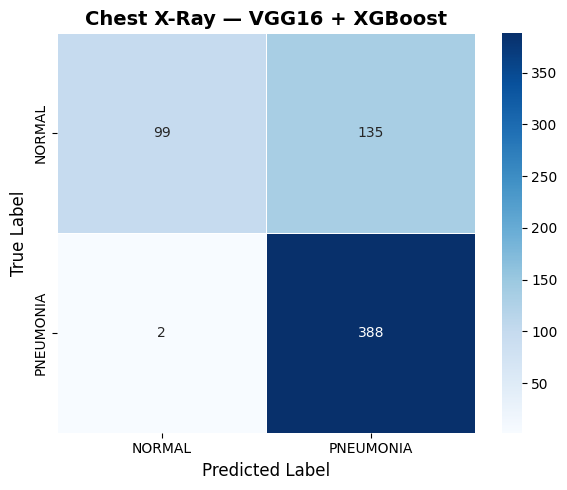

In [17]:
# ==============================================================
# XGBOOST — CHEST X-RAY
# ==============================================================

print("\n" + "="*70)
print("XGBOOST — CHEST X-RAY")
print("="*70)

xgb_chest = XGBClassifier(learning_rate=0.1,
                                  n_estimators=120,
                                  max_depth=4,
                                  subsample=0.8,
                                  colsample_bytree=0.8,
                                  objective='binary:logistic',
                                  eval_metric='logloss',
                                  random_state=SEED,
                                  tree_method='hist',
                                  n_jobs=-1
)

eval_set_chest = [(chest_train_features, train_labels), (chest_val_features, val_labels)]
xgb_chest.fit(chest_train_features,
              train_labels,
              eval_set=eval_set_chest,
              verbose=True
)

# ==============================================================
# CHEST TEST EVALUATION
# ==============================================================

pred_chest = xgb_chest.predict(chest_test_features)
chest_metrics = compute_metrics(test_labels, pred_chest)
print_metrics("CHEST XGBOOST TEST", *chest_metrics[:4])
plot_confusion_matrix(chest_metrics[4], CLASS_NAMES, title='Chest X-Ray — VGG16 + XGBoost')

In [18]:
# ==============================================================
# VGG16 FEATURE EXTRACTION — BRAIN MRI
# ==============================================================

print("\nExtracting VGG16 features for Brain MRI dataset...")

brain_train_features = base_model.predict(brain_train_images, verbose=1)
brain_train_features = brain_train_features.reshape(brain_train_features.shape[0], -1)
del(brain_train_images)
gc.collect()

brain_test_features = base_model.predict(brain_test_images, verbose=1)

brain_test_features = brain_test_features.reshape(brain_test_features.shape[0], -1)
del(brain_test_images)
gc.collect()

print("Brain train features:", brain_train_features.shape)
print("Brain test features :", brain_test_features.shape)


Extracting VGG16 features for Brain MRI dataset...
 2/90 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step

2026-05-18 07:55:17.591689: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step
 2/13 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step 

2026-05-18 07:55:25.873069: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
Brain train features: (2870, 25088)
Brain test features : (394, 25088)



XGBOOST — BRAIN MRI

 BRAIN MRI XGBOOST TEST METRICS
  Accuracy    : 0.7919  (79.19%)
  F1-Score    : 0.7451
  Sensitivity : 0.7919
  Specificity : 0.9279


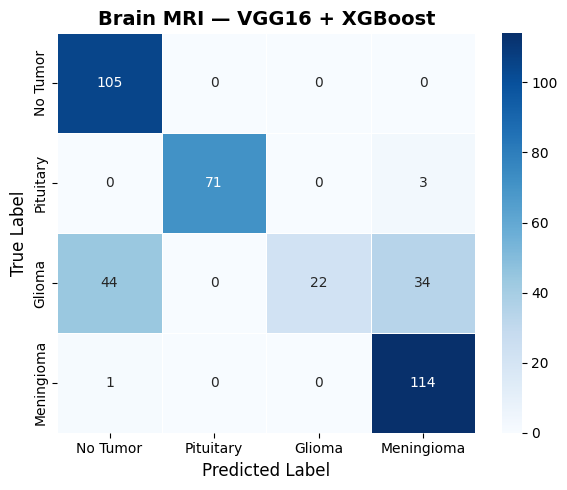

In [19]:
# ==============================================================
# XGBOOST — BRAIN MRI
# ==============================================================

print("\n" + "="*70)
print("XGBOOST — BRAIN MRI")
print("="*70)

xgb_brain = XGBClassifier(learning_rate=0.1,
                                  n_estimators=120,
                                  max_depth=5,
                                  subsample=0.8,
                                  colsample_bytree=0.8,
                                  objective='multi:softmax',
                                  num_class=4,
                                  eval_metric='mlogloss',
                                  random_state=SEED,
                                  tree_method='hist',
                                  n_jobs=-1
)

xgb_brain.fit(brain_train_features, brain_train_labels, verbose=True)

# ==============================================================
# BRAIN TEST EVALUATION
# ==============================================================

pred_brain = xgb_brain.predict(brain_test_features)
brain_metrics = compute_metrics(brain_test_labels, pred_brain)
print_metrics("BRAIN MRI XGBOOST TEST", *brain_metrics[:4])
plot_confusion_matrix(brain_metrics[4], BRAIN_CLASS_NAMES, title='Brain MRI — VGG16 + XGBoost')

# Percentage-Based Training Experiments

Experiments for Original XGBoost, PCA + XGBoost, and VGG16 + XGBoost using 20%, 40%, 60%, 80%, and 100% of training data.  
**Test data is fixed across all experiments.**

In [20]:
# ==============================================================
# PERCENTAGE EXPERIMENT SETUP
# ==============================================================

PERCENTAGES = [0.20, 0.40, 0.60, 0.80, 1.00]
PCT_LABELS  = [20,   40,   60,   80,   100]

print('Percentage experiment constants set.')
print('Percentages:', PERCENTAGES)


Percentage experiment constants set.
Percentages: [0.2, 0.4, 0.6, 0.8, 1.0]


## Part 1 — Original XGBoost: Percentage Experiments

In [21]:
# ==============================================================
# PART 1 — ORIGINAL XGBOOST % EXPERIMENTS — CHEST X-RAY
# ==============================================================

print('\n' + '='*70)
print('PART 1 — ORIGINAL XGBOOST % EXPERIMENTS — CHEST X-RAY')
print('='*70)

chest_xgb_results = {}

for pct in PERCENTAGES:
    n_samples = int(len(X_train_flat) * pct)
    X_sub, y_sub = shuffle(X_train_flat, y_train,
                           random_state=SEED, n_samples=n_samples)

    print(f'\n--- {int(pct*100)}% Training Data ({n_samples} samples) ---')

    model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=SEED
    )
    model.fit(X_sub, y_sub)
    pred = model.predict(X_test_flat)

    acc, f1, sens, spec, cm = compute_metrics(y_test, pred)
    chest_xgb_results[int(pct*100)] = {
        'accuracy': acc, 'f1': f1,
        'sensitivity': sens, 'specificity': spec
    }
    print_metrics(f'XGBoost Chest {int(pct*100)}%', acc, f1, sens, spec)

    del model, X_sub, y_sub
    gc.collect()

print('\nChest X-Ray Original XGBoost % experiments complete.')



PART 1 — ORIGINAL XGBOOST % EXPERIMENTS — CHEST X-RAY

--- 20% Training Data (1043 samples) ---

 XGBoost Chest 20% METRICS
  Accuracy    : 0.7244  (72.44%)
  F1-Score    : 0.6740
  Sensitivity : 0.7244
  Specificity : 0.6359

--- 40% Training Data (2086 samples) ---

 XGBoost Chest 40% METRICS
  Accuracy    : 0.7276  (72.76%)
  F1-Score    : 0.6800
  Sensitivity : 0.7276
  Specificity : 0.6410

--- 60% Training Data (3129 samples) ---

 XGBoost Chest 60% METRICS
  Accuracy    : 0.7308  (73.08%)
  F1-Score    : 0.6827
  Sensitivity : 0.7308
  Specificity : 0.6436

--- 80% Training Data (4172 samples) ---

 XGBoost Chest 80% METRICS
  Accuracy    : 0.7388  (73.88%)
  F1-Score    : 0.6958
  Sensitivity : 0.7388
  Specificity : 0.6551

--- 100% Training Data (5216 samples) ---

 XGBoost Chest 100% METRICS
  Accuracy    : 0.7420  (74.20%)
  F1-Score    : 0.7005
  Sensitivity : 0.7420
  Specificity : 0.6594

Chest X-Ray Original XGBoost % experiments complete.


In [22]:
# ==============================================================
# PART 1 — ORIGINAL XGBOOST % EXPERIMENTS — BRAIN MRI
# ==============================================================

print('\n' + '='*70)
print('PART 1 — ORIGINAL XGBOOST % EXPERIMENTS — BRAIN MRI')
print('='*70)

brain_xgb_results = {}

for pct in PERCENTAGES:
    n_samples = int(len(X_brain_train_flat) * pct)
    X_sub, y_sub = shuffle(X_brain_train_flat, y_brain_train,
                           random_state=SEED, n_samples=n_samples)

    print(f'\n--- {int(pct*100)}% Training Data ({n_samples} samples) ---')

    model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=4,
        eval_metric='mlogloss',
        random_state=SEED
    )
    model.fit(X_sub, y_sub)
    pred = model.predict(X_brain_test_flat)

    acc, f1, sens, spec, cm = compute_metrics(y_brain_test, pred)
    brain_xgb_results[int(pct*100)] = {
        'accuracy': acc, 'f1': f1,
        'sensitivity': sens, 'specificity': spec
    }
    print_metrics(f'XGBoost Brain {int(pct*100)}%', acc, f1, sens, spec)

    del model, X_sub, y_sub
    gc.collect()

print('\nBrain MRI Original XGBoost % experiments complete.')



PART 1 — ORIGINAL XGBOOST % EXPERIMENTS — BRAIN MRI

--- 20% Training Data (574 samples) ---

 XGBoost Brain 20% METRICS
  Accuracy    : 0.4822  (48.22%)
  F1-Score    : 0.4449
  Sensitivity : 0.4822
  Specificity : 0.8250

--- 40% Training Data (1148 samples) ---

 XGBoost Brain 40% METRICS
  Accuracy    : 0.5812  (58.12%)
  F1-Score    : 0.5343
  Sensitivity : 0.5812
  Specificity : 0.8575

--- 60% Training Data (1722 samples) ---

 XGBoost Brain 60% METRICS
  Accuracy    : 0.6066  (60.66%)
  F1-Score    : 0.5661
  Sensitivity : 0.6066
  Specificity : 0.8659

--- 80% Training Data (2296 samples) ---

 XGBoost Brain 80% METRICS
  Accuracy    : 0.6650  (66.50%)
  F1-Score    : 0.6276
  Sensitivity : 0.6650
  Specificity : 0.8855

--- 100% Training Data (2870 samples) ---

 XGBoost Brain 100% METRICS
  Accuracy    : 0.6980  (69.80%)
  F1-Score    : 0.6550
  Sensitivity : 0.6980
  Specificity : 0.8967

Brain MRI Original XGBoost % experiments complete.


## Part 2 — PCA + XGBoost: Percentage Experiments

In [23]:
# ==============================================================
# PART 2 — PCA + XGBOOST % EXPERIMENTS — CHEST X-RAY
# PCA fitted ONLY on current training subset
# ==============================================================

print('\n' + '='*70)
print('PART 2 — PCA + XGBOOST % EXPERIMENTS — CHEST X-RAY')
print('='*70)

chest_pca_xgb_results = {}

for pct in PERCENTAGES:
    n_samples = int(len(X_train_flat) * pct)
    X_sub, y_sub = shuffle(X_train_flat, y_train,
                           random_state=SEED, n_samples=n_samples)

    print(f'\n--- {int(pct*100)}% Training Data ({n_samples} samples) ---')

    # PCA fitted ONLY on the training subset
    pca_sub = PCA(n_components=0.98, random_state=SEED)
    X_sub_pca  = pca_sub.fit_transform(X_sub)
    X_test_pca = pca_sub.transform(X_test_flat)
    print(f'  PCA components: {pca_sub.n_components_}')

    model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=SEED
    )
    model.fit(X_sub_pca, y_sub)
    pred = model.predict(X_test_pca)

    acc, f1, sens, spec, cm = compute_metrics(y_test, pred)
    chest_pca_xgb_results[int(pct*100)] = {
        'accuracy': acc, 'f1': f1,
        'sensitivity': sens, 'specificity': spec
    }
    print_metrics(f'PCA+XGBoost Chest {int(pct*100)}%', acc, f1, sens, spec)

    del model, X_sub, y_sub, pca_sub, X_sub_pca, X_test_pca
    gc.collect()

print('\nChest X-Ray PCA + XGBoost % experiments complete.')



PART 2 — PCA + XGBOOST % EXPERIMENTS — CHEST X-RAY

--- 20% Training Data (1043 samples) ---
  PCA components: 598

 PCA+XGBoost Chest 20% METRICS
  Accuracy    : 0.7163  (71.63%)
  F1-Score    : 0.6718
  Sensitivity : 0.7163
  Specificity : 0.6329

--- 40% Training Data (2086 samples) ---
  PCA components: 985

 PCA+XGBoost Chest 40% METRICS
  Accuracy    : 0.7340  (73.40%)
  F1-Score    : 0.6937
  Sensitivity : 0.7340
  Specificity : 0.6530

--- 60% Training Data (3129 samples) ---
  PCA components: 1281

 PCA+XGBoost Chest 60% METRICS
  Accuracy    : 0.7388  (73.88%)
  F1-Score    : 0.7025
  Sensitivity : 0.7388
  Specificity : 0.6611

--- 80% Training Data (4172 samples) ---
  PCA components: 1526

 PCA+XGBoost Chest 80% METRICS
  Accuracy    : 0.7580  (75.80%)
  F1-Score    : 0.7268
  Sensitivity : 0.7580
  Specificity : 0.6842

--- 100% Training Data (5216 samples) ---
  PCA components: 1723

 PCA+XGBoost Chest 100% METRICS
  Accuracy    : 0.7484  (74.84%)
  F1-Score    : 0.7125

In [24]:
# ==============================================================
# PART 2 — PCA + XGBOOST % EXPERIMENTS — BRAIN MRI
# PCA fitted ONLY on current training subset
# ==============================================================

print('\n' + '='*70)
print('PART 2 — PCA + XGBOOST % EXPERIMENTS — BRAIN MRI')
print('='*70)

brain_pca_xgb_results = {}

for pct in PERCENTAGES:
    n_samples = int(len(X_brain_train_flat) * pct)
    X_sub, y_sub = shuffle(X_brain_train_flat, y_brain_train,
                           random_state=SEED, n_samples=n_samples)

    print(f'\n--- {int(pct*100)}% Training Data ({n_samples} samples) ---')

    pca_sub = PCA(n_components=0.98, random_state=SEED)
    X_sub_pca       = pca_sub.fit_transform(X_sub)
    X_brain_test_pca = pca_sub.transform(X_brain_test_flat)
    print(f'  PCA components: {pca_sub.n_components_}')

    model = XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=4,
        eval_metric='mlogloss',
        random_state=SEED
    )
    model.fit(X_sub_pca, y_sub)
    pred = model.predict(X_brain_test_pca)

    acc, f1, sens, spec, cm = compute_metrics(y_brain_test, pred)
    brain_pca_xgb_results[int(pct*100)] = {
        'accuracy': acc, 'f1': f1,
        'sensitivity': sens, 'specificity': spec
    }
    print_metrics(f'PCA+XGBoost Brain {int(pct*100)}%', acc, f1, sens, spec)

    del model, X_sub, y_sub, pca_sub, X_sub_pca, X_brain_test_pca
    gc.collect()

print('\nBrain MRI PCA + XGBoost % experiments complete.')



PART 2 — PCA + XGBOOST % EXPERIMENTS — BRAIN MRI

--- 20% Training Data (574 samples) ---
  PCA components: 429

 PCA+XGBoost Brain 20% METRICS
  Accuracy    : 0.4898  (48.98%)
  F1-Score    : 0.4655
  Sensitivity : 0.4898
  Specificity : 0.8299

--- 40% Training Data (1148 samples) ---
  PCA components: 772

 PCA+XGBoost Brain 40% METRICS
  Accuracy    : 0.6193  (61.93%)
  F1-Score    : 0.5907
  Sensitivity : 0.6193
  Specificity : 0.8725

--- 60% Training Data (1722 samples) ---
  PCA components: 1058

 PCA+XGBoost Brain 60% METRICS
  Accuracy    : 0.7030  (70.30%)
  F1-Score    : 0.6724
  Sensitivity : 0.7030
  Specificity : 0.8997

--- 80% Training Data (2296 samples) ---
  PCA components: 1291

 PCA+XGBoost Brain 80% METRICS
  Accuracy    : 0.7741  (77.41%)
  F1-Score    : 0.7318
  Sensitivity : 0.7741
  Specificity : 0.9249

--- 100% Training Data (2870 samples) ---
  PCA components: 1505

 PCA+XGBoost Brain 100% METRICS
  Accuracy    : 0.7817  (78.17%)
  F1-Score    : 0.7379
  

## Part 3 — VGG16 + XGBoost: Percentage Experiments

In [25]:
# ==============================================================
# PART 3 — VGG16 + XGBOOST % EXPERIMENTS — CHEST X-RAY
# Uses already-extracted chest_train_features (frozen VGG16)
# ==============================================================

print('\n' + '='*70)
print('PART 3 — VGG16 + XGBOOST % EXPERIMENTS — CHEST X-RAY')
print('='*70)

chest_vgg_xgb_results = {}

for pct in PERCENTAGES:
    n_samples = int(len(chest_train_features) * pct)
    feat_sub, label_sub = shuffle(chest_train_features, train_labels,
                                  random_state=SEED, n_samples=n_samples)

    print(f'\n--- {int(pct*100)}% Training Data ({n_samples} samples) ---')

    model = XGBClassifier(
        learning_rate=0.1,
        n_estimators=120,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=SEED,
        tree_method='hist',
        n_jobs=-1
    )
    model.fit(feat_sub, label_sub)
    pred = model.predict(chest_test_features)

    acc, f1, sens, spec, cm = compute_metrics(test_labels, pred)
    chest_vgg_xgb_results[int(pct*100)] = {
        'accuracy': acc, 'f1': f1,
        'sensitivity': sens, 'specificity': spec
    }
    print_metrics(f'VGG16+XGBoost Chest {int(pct*100)}%', acc, f1, sens, spec)

    del model, feat_sub, label_sub
    gc.collect()

print('\nChest X-Ray VGG16 + XGBoost % experiments complete.')



PART 3 — VGG16 + XGBOOST % EXPERIMENTS — CHEST X-RAY

--- 20% Training Data (1043 samples) ---

 VGG16+XGBoost Chest 20% METRICS
  Accuracy    : 0.7516  (75.16%)
  F1-Score    : 0.7135
  Sensitivity : 0.7516
  Specificity : 0.6714

--- 40% Training Data (2086 samples) ---

 VGG16+XGBoost Chest 40% METRICS
  Accuracy    : 0.7564  (75.64%)
  F1-Score    : 0.7204
  Sensitivity : 0.7564
  Specificity : 0.6778

--- 60% Training Data (3129 samples) ---

 VGG16+XGBoost Chest 60% METRICS
  Accuracy    : 0.7564  (75.64%)
  F1-Score    : 0.7204
  Sensitivity : 0.7564
  Specificity : 0.6778

--- 80% Training Data (4172 samples) ---

 VGG16+XGBoost Chest 80% METRICS
  Accuracy    : 0.7484  (74.84%)
  F1-Score    : 0.7089
  Sensitivity : 0.7484
  Specificity : 0.6671

--- 100% Training Data (5216 samples) ---

 VGG16+XGBoost Chest 100% METRICS
  Accuracy    : 0.7756  (77.56%)
  F1-Score    : 0.7456
  Sensitivity : 0.7756
  Specificity : 0.7017

Chest X-Ray VGG16 + XGBoost % experiments complete.


In [26]:
# ==============================================================
# PART 3 — VGG16 + XGBOOST % EXPERIMENTS — BRAIN MRI
# Uses already-extracted brain_train_features (frozen VGG16)
# ==============================================================

print('\n' + '='*70)
print('PART 3 — VGG16 + XGBOOST % EXPERIMENTS — BRAIN MRI')
print('='*70)

brain_vgg_xgb_results = {}

for pct in PERCENTAGES:
    n_samples = int(len(brain_train_features) * pct)
    feat_sub, label_sub = shuffle(brain_train_features, brain_train_labels,
                                  random_state=SEED, n_samples=n_samples)

    print(f'\n--- {int(pct*100)}% Training Data ({n_samples} samples) ---')

    model = XGBClassifier(
        learning_rate=0.1,
        n_estimators=120,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=4,
        eval_metric='mlogloss',
        random_state=SEED,
        tree_method='hist',
        n_jobs=-1
    )
    model.fit(feat_sub, label_sub)
    pred = model.predict(brain_test_features)

    acc, f1, sens, spec, cm = compute_metrics(brain_test_labels, pred)
    brain_vgg_xgb_results[int(pct*100)] = {
        'accuracy': acc, 'f1': f1,
        'sensitivity': sens, 'specificity': spec
    }
    print_metrics(f'VGG16+XGBoost Brain {int(pct*100)}%', acc, f1, sens, spec)

    del model, feat_sub, label_sub
    gc.collect()

print('\nBrain MRI VGG16 + XGBoost % experiments complete.')



PART 3 — VGG16 + XGBOOST % EXPERIMENTS — BRAIN MRI

--- 20% Training Data (574 samples) ---

 VGG16+XGBoost Brain 20% METRICS
  Accuracy    : 0.6244  (62.44%)
  F1-Score    : 0.5934
  Sensitivity : 0.6244
  Specificity : 0.8741

--- 40% Training Data (1148 samples) ---

 VGG16+XGBoost Brain 40% METRICS
  Accuracy    : 0.7157  (71.57%)
  F1-Score    : 0.6791
  Sensitivity : 0.7157
  Specificity : 0.9031

--- 60% Training Data (1722 samples) ---

 VGG16+XGBoost Brain 60% METRICS
  Accuracy    : 0.7386  (73.86%)
  F1-Score    : 0.6982
  Sensitivity : 0.7386
  Specificity : 0.9099

--- 80% Training Data (2296 samples) ---

 VGG16+XGBoost Brain 80% METRICS
  Accuracy    : 0.7741  (77.41%)
  F1-Score    : 0.7300
  Sensitivity : 0.7741
  Specificity : 0.9220

--- 100% Training Data (2870 samples) ---

 VGG16+XGBoost Brain 100% METRICS
  Accuracy    : 0.7766  (77.66%)
  F1-Score    : 0.7295
  Sensitivity : 0.7766
  Specificity : 0.9226

Brain MRI VGG16 + XGBoost % experiments complete.


## Results Tables

In [27]:
# ==============================================================
# EXPERIMENT RESULTS TABLE — CHEST X-RAY
# ==============================================================

print('\n' + '='*70)
print('EXPERIMENT RESULTS TABLE — CHEST X-RAY')
print('='*70)

metrics_keys = ['accuracy', 'f1', 'sensitivity', 'specificity']
metrics_labels = ['Accuracy', 'F1-Score', 'Sensitivity', 'Specificity']

rows_chest = []
for pct in PCT_LABELS:
    row = {'Training %': pct}
    for mk in metrics_keys:
        row[f'XGBoost_{mk}']       = round(chest_xgb_results[pct][mk], 4)
        row[f'PCA+XGBoost_{mk}']   = round(chest_pca_xgb_results[pct][mk], 4)
        row[f'VGG16+XGBoost_{mk}'] = round(chest_vgg_xgb_results[pct][mk], 4)
    rows_chest.append(row)

df_chest_results = pd.DataFrame(rows_chest).set_index('Training %')

for mk, ml in zip(metrics_keys, metrics_labels):
    print(f'\n{ml}:')
    cols = [f'XGBoost_{mk}', f'PCA+XGBoost_{mk}', f'VGG16+XGBoost_{mk}']
    sub = df_chest_results[cols].copy()
    sub.columns = ['XGBoost', 'PCA+XGBoost', 'VGG16+XGBoost']
    print(sub.to_string())

print('\nFull Results DataFrame (Chest X-Ray):')
print(df_chest_results.to_string())



EXPERIMENT RESULTS TABLE — CHEST X-RAY

Accuracy:
            XGBoost  PCA+XGBoost  VGG16+XGBoost
Training %                                     
20           0.7244       0.7163         0.7516
40           0.7276       0.7340         0.7564
60           0.7308       0.7388         0.7564
80           0.7388       0.7580         0.7484
100          0.7420       0.7484         0.7756

F1-Score:
            XGBoost  PCA+XGBoost  VGG16+XGBoost
Training %                                     
20           0.6740       0.6718         0.7135
40           0.6800       0.6937         0.7204
60           0.6827       0.7025         0.7204
80           0.6958       0.7268         0.7089
100          0.7005       0.7125         0.7456

Sensitivity:
            XGBoost  PCA+XGBoost  VGG16+XGBoost
Training %                                     
20           0.7244       0.7163         0.7516
40           0.7276       0.7340         0.7564
60           0.7308       0.7388         0.7564
80          

In [28]:
# ==============================================================
# EXPERIMENT RESULTS TABLE — BRAIN MRI
# ==============================================================

print('\n' + '='*70)
print('EXPERIMENT RESULTS TABLE — BRAIN MRI')
print('='*70)

rows_brain = []
for pct in PCT_LABELS:
    row = {'Training %': pct}
    for mk in metrics_keys:
        row[f'XGBoost_{mk}']       = round(brain_xgb_results[pct][mk], 4)
        row[f'PCA+XGBoost_{mk}']   = round(brain_pca_xgb_results[pct][mk], 4)
        row[f'VGG16+XGBoost_{mk}'] = round(brain_vgg_xgb_results[pct][mk], 4)
    rows_brain.append(row)

df_brain_results = pd.DataFrame(rows_brain).set_index('Training %')

for mk, ml in zip(metrics_keys, metrics_labels):
    print(f'\n{ml}:')
    cols = [f'XGBoost_{mk}', f'PCA+XGBoost_{mk}', f'VGG16+XGBoost_{mk}']
    sub = df_brain_results[cols].copy()
    sub.columns = ['XGBoost', 'PCA+XGBoost', 'VGG16+XGBoost']
    print(sub.to_string())

print('\nFull Results DataFrame (Brain MRI):')
print(df_brain_results.to_string())



EXPERIMENT RESULTS TABLE — BRAIN MRI

Accuracy:
            XGBoost  PCA+XGBoost  VGG16+XGBoost
Training %                                     
20           0.4822       0.4898         0.6244
40           0.5812       0.6193         0.7157
60           0.6066       0.7030         0.7386
80           0.6650       0.7741         0.7741
100          0.6980       0.7817         0.7766

F1-Score:
            XGBoost  PCA+XGBoost  VGG16+XGBoost
Training %                                     
20           0.4449       0.4655         0.5934
40           0.5343       0.5907         0.6791
60           0.5661       0.6724         0.6982
80           0.6276       0.7318         0.7300
100          0.6550       0.7379         0.7295

Sensitivity:
            XGBoost  PCA+XGBoost  VGG16+XGBoost
Training %                                     
20           0.4822       0.4898         0.6244
40           0.5812       0.6193         0.7157
60           0.6066       0.7030         0.7386
80           0

## Comparison Plots


COMPARISON PLOTS — CHEST X-RAY


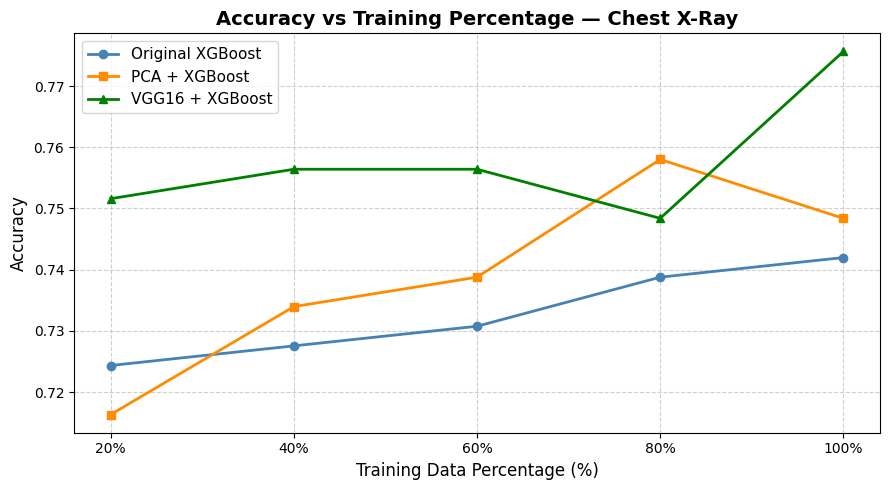

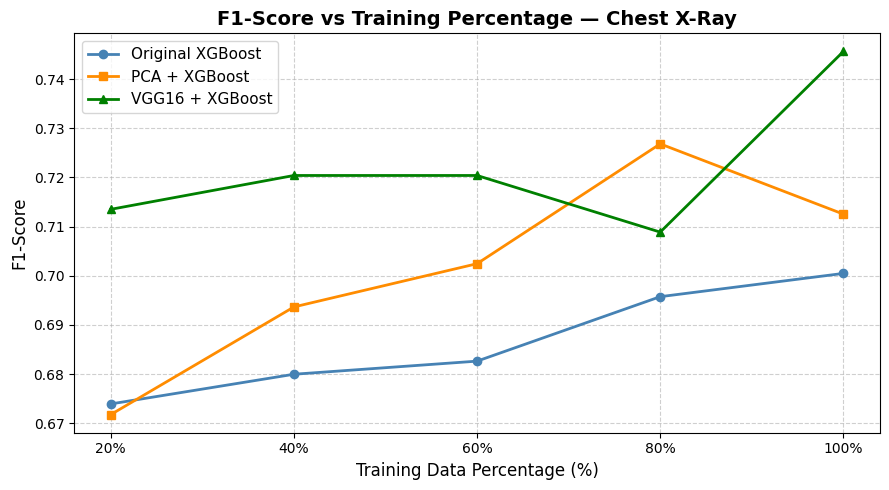

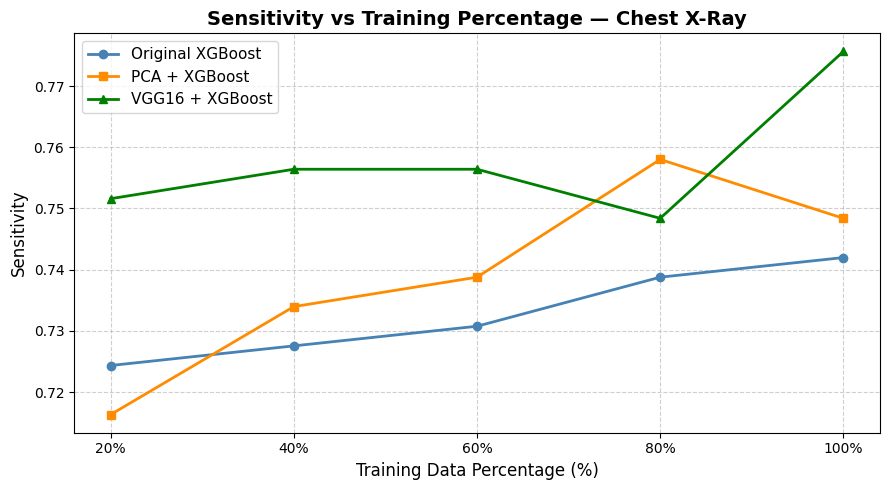

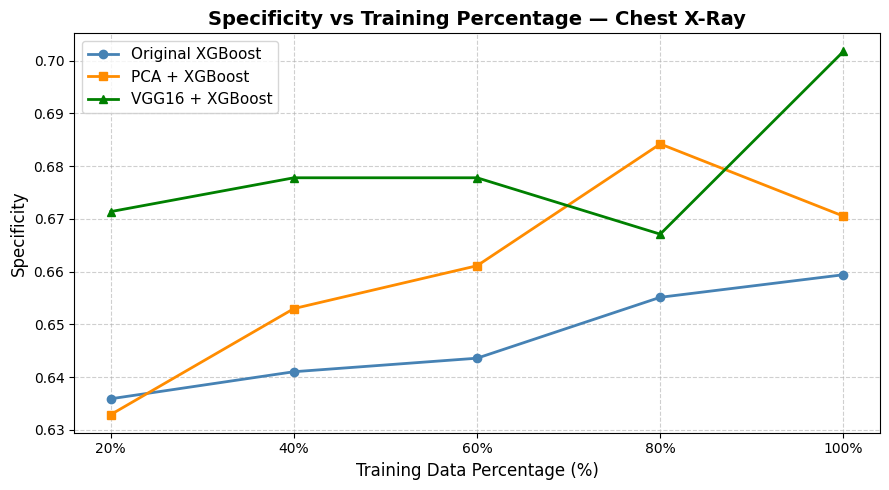

In [29]:
# ==============================================================
# HELPER: Plot metric vs training percentage for three methods
# ==============================================================

def plot_percentage_comparison(results_xgb, results_pca, results_vgg,
                               metric, metric_label, dataset_name):
    """Plot a single metric across training percentages for 3 methods."""
    xgb_vals = [results_xgb[p][metric] for p in PCT_LABELS]
    pca_vals = [results_pca[p][metric]  for p in PCT_LABELS]
    vgg_vals = [results_vgg[p][metric]  for p in PCT_LABELS]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(PCT_LABELS, xgb_vals, marker='o', linewidth=2,
            label='Original XGBoost', color='steelblue')
    ax.plot(PCT_LABELS, pca_vals, marker='s', linewidth=2,
            label='PCA + XGBoost',    color='darkorange')
    ax.plot(PCT_LABELS, vgg_vals, marker='^', linewidth=2,
            label='VGG16 + XGBoost',  color='green')

    ax.set_xlabel('Training Data Percentage (%)', fontsize=12)
    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_title(
        f'{metric_label} vs Training Percentage — {dataset_name}',
        fontsize=14, fontweight='bold'
    )
    ax.set_xticks(PCT_LABELS)
    ax.set_xticklabels([f'{p}%' for p in PCT_LABELS])
    ax.legend(fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


print('\n' + '='*70)
print('COMPARISON PLOTS — CHEST X-RAY')
print('='*70)

plot_percentage_comparison(
    chest_xgb_results, chest_pca_xgb_results, chest_vgg_xgb_results,
    'accuracy', 'Accuracy', 'Chest X-Ray')

plot_percentage_comparison(
    chest_xgb_results, chest_pca_xgb_results, chest_vgg_xgb_results,
    'f1', 'F1-Score', 'Chest X-Ray')

plot_percentage_comparison(
    chest_xgb_results, chest_pca_xgb_results, chest_vgg_xgb_results,
    'sensitivity', 'Sensitivity', 'Chest X-Ray')

plot_percentage_comparison(
    chest_xgb_results, chest_pca_xgb_results, chest_vgg_xgb_results,
    'specificity', 'Specificity', 'Chest X-Ray')



COMPARISON PLOTS — BRAIN MRI


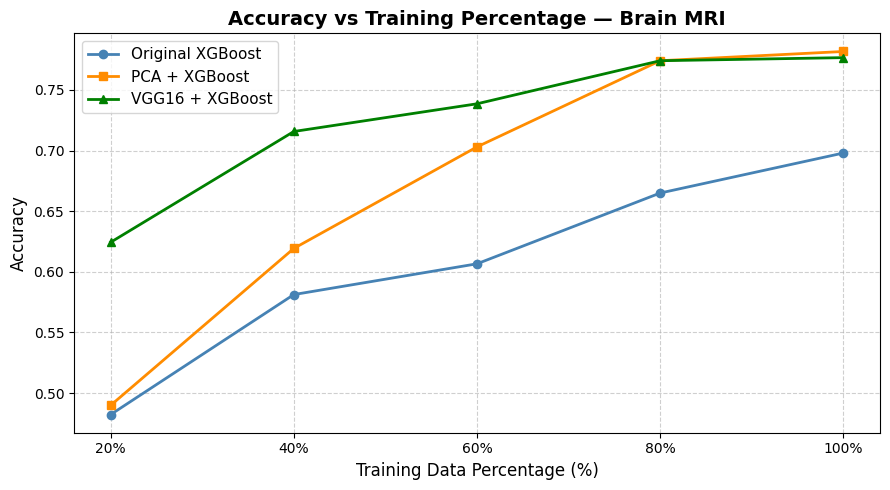

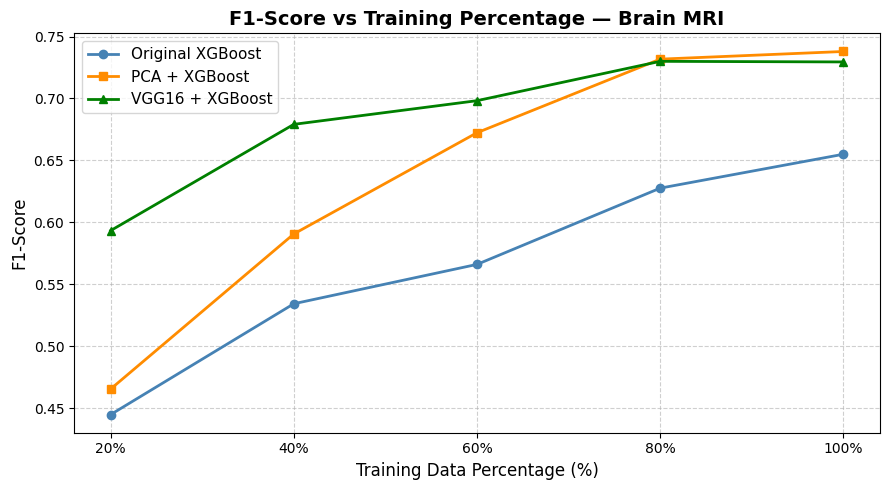

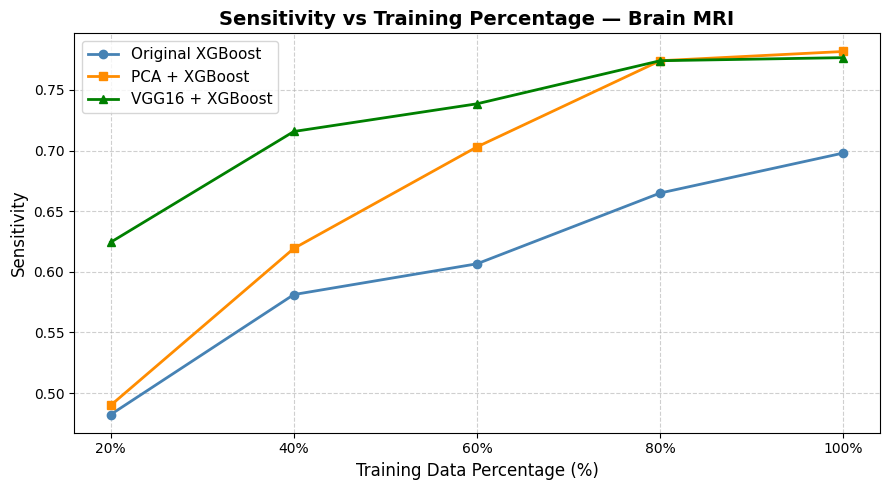

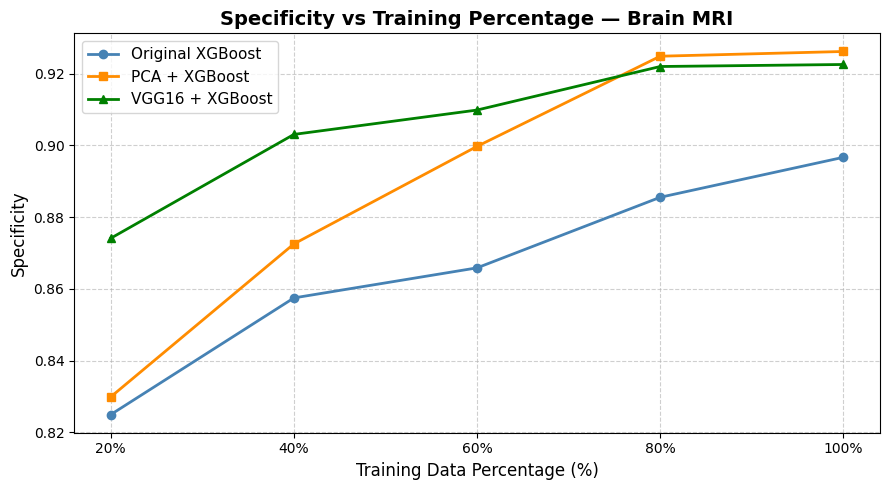

In [30]:
# ==============================================================
# COMPARISON PLOTS — BRAIN MRI
# ==============================================================

print('\n' + '='*70)
print('COMPARISON PLOTS — BRAIN MRI')
print('='*70)

plot_percentage_comparison(
    brain_xgb_results, brain_pca_xgb_results, brain_vgg_xgb_results,
    'accuracy', 'Accuracy', 'Brain MRI')

plot_percentage_comparison(
    brain_xgb_results, brain_pca_xgb_results, brain_vgg_xgb_results,
    'f1', 'F1-Score', 'Brain MRI')

plot_percentage_comparison(
    brain_xgb_results, brain_pca_xgb_results, brain_vgg_xgb_results,
    'sensitivity', 'Sensitivity', 'Brain MRI')

plot_percentage_comparison(
    brain_xgb_results, brain_pca_xgb_results, brain_vgg_xgb_results,
    'specificity', 'Specificity', 'Brain MRI')
